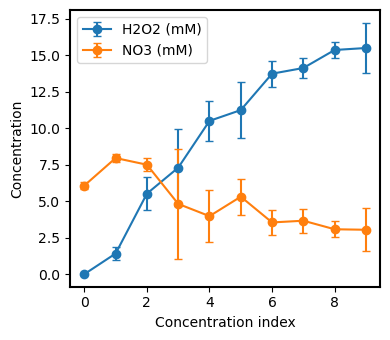

In [2]:
import numpy as np
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# =========================
# Hill
# =========================
def hill(x,A,B,C,N):
    x = np.clip(x,1e-12,1e6)
    return A*(x**N)/(B**N+x**N)+C


# =========================
# params
# =========================
H2O2_params = {
"GC":[0.793063901,0.003510244,0.07686459,0.936160936],
"TG":[0.855612178,0.000794612,0.070094087,0.758826963],
}

NO3_params = {
"GC":[0.913292006,0.003669045,1.94032e-23,1.661215552],
"TG":[0.928907612,0.004846066,2.51132e-21,1.20922578],
}

param_sets = [H2O2_params, NO3_params]
species = ["H2O2","NO3"]
seqs = ["TG","GC"]


# =========================
# data
# =========================
TG_resp = np.array([0.48012651,0.59856344,0.66119663,0.69969722,0.71588693,
                    0.7188739,0.74630066,0.74795219,0.76102735,0.76658046])

GC_resp = np.array([0.67776469, 0.65727119, 0.64020226, 0.5975564 , 0.61679685,
                    0.64789904, 0.64639283, 0.64958746, 0.65791527, 0.66232017])

TG_std = np.array([0.02007448, 0.00977535, 0.01471064, 0.02528117, 0.01662754,
                   0.01787102, 0.01074051, 0.00294758, 0.00496327, 0.00377806])

GC_std = np.array([0.02283693, 0.01149788, 0.00745796, 0.08028114, 0.02769502,
                   0.00885443, 0.00930058, 0.01226045, 0.00675976, 0.01910955])


# =========================
# inverse solver
# =========================
def solve_inverse(R_target):

    def objective(x):
        x_sum = np.sum(x)
        error = 0

        for j in range(2):
            seq = seqs[j]
            Ri_pred = 0

            for k in range(2):
                A,B,C,N = param_sets[k][seq]
                Ri_pred += (x[k]/x_sum)*hill(x[k],A,B,C,N)

            error += (Ri_pred - R_target[j])**2

        return error

    bounds = [(1e-5,1e-1),(1e-3,1e-1)]
    x0 = [1e-3,1e-2]

    result = minimize(objective, x0=x0, bounds=bounds, method="SLSQP")
    return result.x


# =========================
# Monte Carlo
# =========================
N_MC = 200

H2O2_mean = []
H2O2_std_out = []

NO3_mean = []
NO3_std_out = []

for i in range(len(TG_resp)):

    samples = []

    for n in range(N_MC):

        # noise 추가
        TG_noisy = np.random.normal(TG_resp[i], TG_std[i])
        GC_noisy = np.random.normal(GC_resp[i], GC_std[i])

        R_target = [TG_noisy, GC_noisy]

        sol = solve_inverse(R_target)
        samples.append(sol)

    samples = np.array(samples)

    # mean + std
    H2O2_mean.append(np.mean(samples[:,0])*1000)
    H2O2_std_out.append(np.std(samples[:,0])*1000)

    NO3_mean.append(np.mean(samples[:,1])*1000)
    NO3_std_out.append(np.std(samples[:,1])*1000)


H2O2_mean = np.array(H2O2_mean)
H2O2_std_out = np.array(H2O2_std_out)

NO3_mean = np.array(NO3_mean)
NO3_std_out = np.array(NO3_std_out)


# =========================
# plot
# =========================
plt.figure(figsize=(4,3.5))

x = np.arange(len(TG_resp))

plt.errorbar(x, H2O2_mean, yerr=H2O2_std_out,
             fmt='o-', capsize=3, label="H2O2 (mM)")

plt.errorbar(x, NO3_mean, yerr=NO3_std_out,
             fmt='o-', capsize=3, label="NO3 (mM)")

# 축 스타일
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.xlabel("Concentration index")
plt.ylabel("Concentration")
plt.legend()

plt.tight_layout()
plt.show()